First 5 rows of dataset:
   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023-05-21     CUST004    Male   37         Clothing   
4               5  2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30  
3         1             500           500  
4         2              50           100  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   in

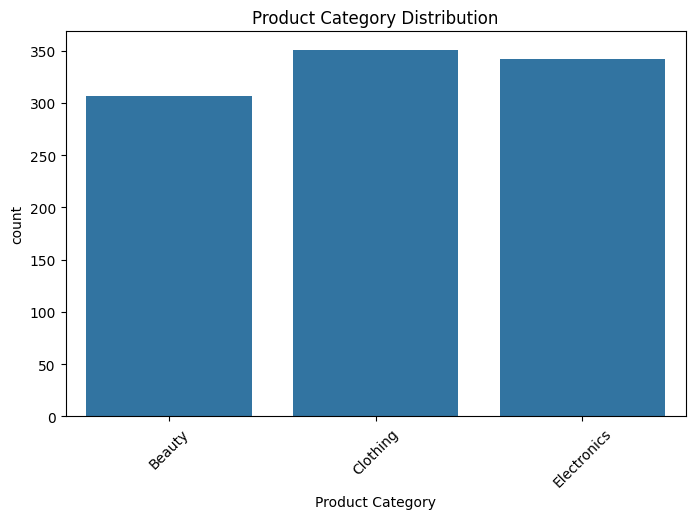

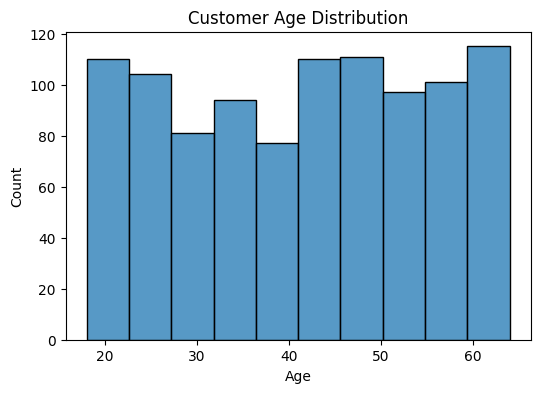

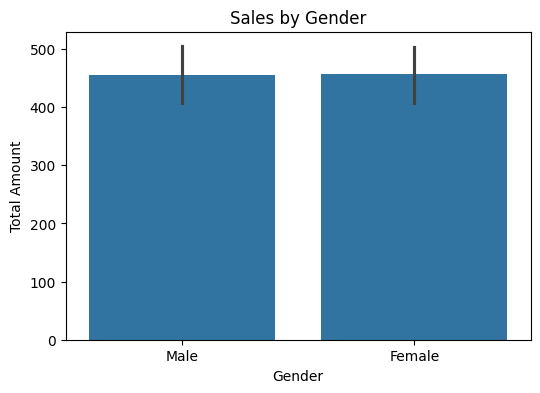

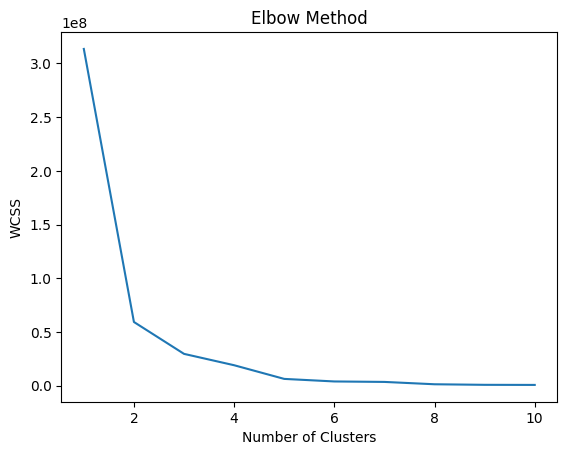


Dataset with Segment Column:
   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023-05-21     CUST004    Male   37         Clothing   
4               5  2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount  Calculated Total  Segment  
0         3              50           150               150        0  
1         2             500          1000              1000        1  
2         1              30            30                30        0  
3         1             500           500               500        0  
4         2              50           100               100        0  


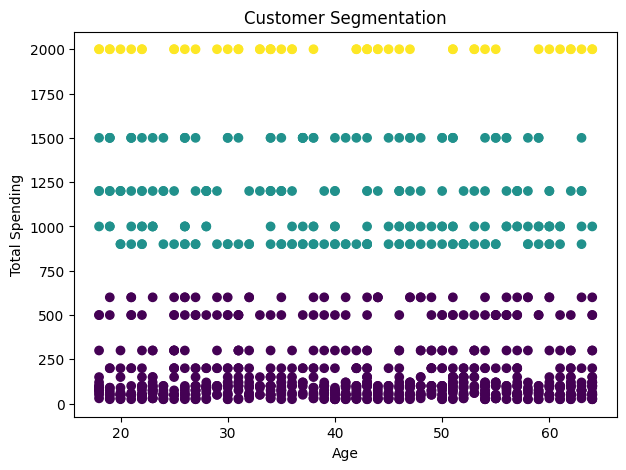


Segment Analysis:
               Age  Quantity  Total Amount
Segment                                   
0        41.841033  2.266304    154.076087
1        40.232558  3.023256   1137.674419
2        39.734694  4.000000   2000.000000


In [2]:
# ==============================
# Customer Segmentation Analysis
# ==============================

# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# ------------------------------
# Load Dataset
# ------------------------------

data = pd.read_csv("retail_sales_dataset.csv")

print("First 5 rows of dataset:")
print(data.head())

# ------------------------------
# Dataset Information
# ------------------------------

print("\nDataset Information:")
print(data.info())

print("\nStatistical Summary:")
print(data.describe())

# ------------------------------
# Check Missing Values
# ------------------------------

print("\nMissing Values:")
print(data.isnull().sum())

# Remove missing values if present
data = data.dropna()

# ------------------------------
# Basic Data Analysis
# ------------------------------

# Total Sales
total_sales = data["Total Amount"].sum()
print("\nTotal Sales:", total_sales)

# Average Purchase
avg_purchase = data["Total Amount"].mean()
print("Average Purchase Value:", avg_purchase)

# Most Popular Product Category
print("\nProduct Category Count:")
print(data["Product Category"].value_counts())

# ------------------------------
# Verify Total Amount
# ------------------------------

data["Calculated Total"] = data["Quantity"] * data["Price per Unit"]

# ------------------------------
# Data Visualization
# ------------------------------

# Product Category Distribution
plt.figure(figsize=(8,5))
sns.countplot(x="Product Category", data=data)
plt.title("Product Category Distribution")
plt.xticks(rotation=45)
plt.show()

# Age Distribution
plt.figure(figsize=(6,4))
sns.histplot(data["Age"], bins=10)
plt.title("Customer Age Distribution")
plt.show()

# Sales by Gender
plt.figure(figsize=(6,4))
sns.barplot(x="Gender", y="Total Amount", data=data)
plt.title("Sales by Gender")
plt.show()

# ------------------------------
# Elbow Method (Find best K)
# ------------------------------

X = data[["Age", "Quantity", "Total Amount"]]

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

# ------------------------------
# Apply K-Means Clustering
# ------------------------------

kmeans = KMeans(n_clusters=3)

data["Segment"] = kmeans.fit_predict(X)

print("\nDataset with Segment Column:")
print(data.head())

# ------------------------------
# Visualize Customer Segments
# ------------------------------

plt.figure(figsize=(7,5))

plt.scatter(data["Age"], data["Total Amount"], c=data["Segment"])

plt.xlabel("Age")
plt.ylabel("Total Spending")
plt.title("Customer Segmentation")

plt.show()

# ------------------------------
# Segment Analysis
# ------------------------------

print("\nSegment Analysis:")
segment_analysis = data.groupby("Segment")[["Age","Quantity","Total Amount"]].mean()

print(segment_analysis)

# ------------------------------
# End of Project
# ------------------------------

Data Exploration

The dataset was explored to understand its structure, columns, and statistical properties.

Visualization

Graphs were created to analyze customer age distribution, product category popularity, and sales patterns.

Customer Segmentation

K-Means clustering was applied to group customers into segments based on age, quantity purchased, and total spending.

Insights

Customers in Segment 0 have moderate spending behavior.

Customers in Segment 1 show higher purchase quantities.

Customers in Segment 2 represent high-value customers with higher spending.

Business Recommendation

Businesses can target high-value customers with premium offers and encourage moderate customers with discounts or loyalty programs